In [76]:
import utils
import numpy as np
import pandas as pd
import os
from scipy.stats import chisquare

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme
sns.set_theme()

pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_rows', None)

In [77]:
# Make output folder
output_dir = os.path.join('..','plots','behavioural_pilot','reaction_time')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [78]:
# Preparation
experiment_output_path = os.path.join('..', '..', 'phd_1_task', 'experiment_output', 'behavioural_files')

In [79]:
unique_subject_ids = [999]
unique_sessions = [23]

recent_results = utils.analysis_functions.list_files_with_date_and_subject_id(experiment_output_path, unique_subject_ids, unique_sessions)

In [80]:
print(recent_results)

['../../phd_1_task/experiment_output/behavioural_files/experiment_output_sub-999_session-23_computer_and_keyboard_2024-06-12_18-02-24.csv']


In [81]:
combined_dataframe = utils.analysis_functions.combine_result_files(recent_results)
print(combined_dataframe)

     trial  emotional_cue_time response objectively_correct  \
0        0        1.718208e+09     down                Even   
1        1        1.718208e+09     down                Even   
2        2        1.718208e+09     down                Even   
3        3        1.718208e+09       up                Even   
4        4        1.718208e+09       up                Even   
5        5        1.718208e+09       up                Even   
6        6        1.718208e+09       up                Even   
7        7        1.718208e+09       up                Even   
8        8        1.718208e+09     down                True   
9        9        1.718208e+09     down               False   
10      10        1.718208e+09     down               False   
11      11        1.718208e+09       up               False   
12      12        1.718208e+09       up                True   
13      13        1.718208e+09       up               False   
14      14        1.718208e+09     down               F

# Analysis
First, we'll look at the reaction time. A plot with all the RT's and average will do.
Second we will look at the percentage of correct answers.
Lastly, we will be looking at a win-stay lose shift to see when behaviour stabilises after a shift in reward contingency.

In [82]:
# Count amount of subplots necessary based on subject_id's and sessions
## Finds unique values
unique_subject_ids = combined_dataframe['subject_id'].unique()
unique_sessions = combined_dataframe['session'].unique()

## Calculates the number of subplots needed
n_rows = len(unique_subject_ids)
n_cols = len(unique_sessions)
n_subplots = len(unique_sessions) * len(unique_subject_ids)

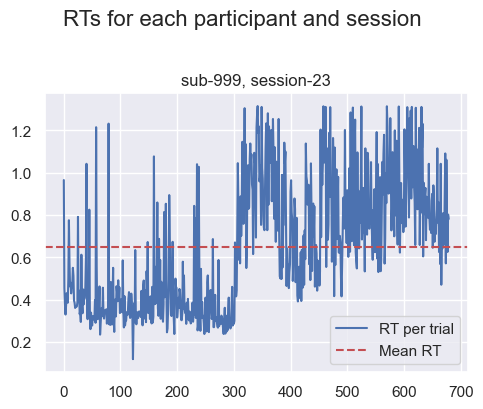

In [83]:
# Raw RT
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4), sharex=True, sharey=True)
fig.suptitle('RTs for each participant and session', fontsize=16, y=1.02)

if n_rows == 1 or n_cols == 1:
    axes = np.array(axes).reshape(n_rows, n_cols)

## Loop through each combination of 'session' and 'subject_id' and create a plot
for i, session in enumerate(unique_sessions):
    for j, subject_id in enumerate(unique_subject_ids):
        ax_index = j * len(unique_sessions) + i
        ax = axes[j, i]

        ## Filter the dataframe for the current session and subject_id
        subset = combined_dataframe[(combined_dataframe['session'] == session) & (combined_dataframe['subject_id'] == subject_id)]

        ## Plot
        ax.plot(subset['RT_s'].values, label=f'RT per trial')
        ax.axhline(subset['RT_s'].mean(), color='r', linestyle='--', label='Mean RT')
        ax.set_title(f'{subject_id}, {session}')
        ax.legend()

## Adjust layout
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'RT_for_each_participant_and_session.pdf'))
plt.show()

# Check congruency, valence and volatility

In [95]:
# Check a block's congruency
combined_dataframe['congruency'] = combined_dataframe.apply(utils.analysis_functions.check_congruency, axis=1)

# Check a block's valence
combined_dataframe['valence'] = combined_dataframe.apply(utils.analysis_functions.check_valence, axis=1)

# Check a block's volatility
combined_dataframe = combined_dataframe[combined_dataframe['probability_condition'] != 50]
combined_dataframe = utils.analysis_functions.check_volatility(combined_dataframe)
combined_dataframe = combined_dataframe.sort_values(by=['subject_id', 'session', 'stimuli_type', 'trial'], ascending=[True, True, True, True])

# Cut out the first block for your volatility measure
def slice_on_switch(group):
    # Find the index where the value switches
    switch_index = group['probability_condition'].diff().ne(0)#.idxmax()
    true_indices = switch_index[switch_index].index.tolist()
    print(true_indices)
    if len(true_indices) > 1:
        second_true_index = true_indices[1]
    else:
        second_true_index = None
    # Slice the group from the switch point
    return group.iloc[second_true_index:]

# Apply the function to each group
dataframe_without_volatility = combined_dataframe.groupby('stimuli_type', group_keys=False).apply(slice_on_switch)
dataframe_with_volatility = combined_dataframe

[0, 56, 122, 142, 164, 185, 208, 273, 328, 356, 376, 405, 430, 493, 550, 577, 596, 622, 649]
     trial  emotional_cue_time response objectively_correct  \
0        8        1.718208e+09     down                True   
3       11        1.718208e+09       up               False   
5       13        1.718208e+09       up               False   
7       15        1.718208e+09     down                True   
10      18        1.718208e+09     down                True   
11      19        1.718208e+09     down                True   
12      20        1.718208e+09       up               False   
14      22        1.718208e+09       up               False   
17      25        1.718208e+09       up               False   
18      26        1.718208e+09       up               False   
20      28        1.718208e+09       up               False   
21      29        1.718208e+09     down                True   
24      32        1.718208e+09       up               False   
26      34        1.71820

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5463/2451264802.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dataframe_without_volatility = combined_dataframe.groupby('stimuli_type', group_keys=False).apply(slice_on_switch)


In [85]:
print(dataframe_without_volatility[['trial','stimuli_type','probability_condition']])
print(dataframe_with_volatility[['trial','stimuli_type','probability_condition']])

     trial  stimuli_type  probability_condition
112    120             1                     80
114    122             1                     80
118    126             1                     80
119    127             1                     80
122    130             1                     20
123    131             1                     20
124    132             1                     20
126    134             1                     20
130    138             1                     20
131    139             1                     20
133    141             1                     20
134    142             1                     20
136    144             1                     20
137    145             1                     20
142    150             1                     80
143    151             1                     80
144    152             1                     80
147    155             1                     80
149    157             1                     80
151    159             1                

# Plot average RT for different groups
- Valence
- Volatility
- Congruency
- Valence/Volatility
- Congruency/Volatility
- Valence/Congruency
- Valence/Congruency/Volatility

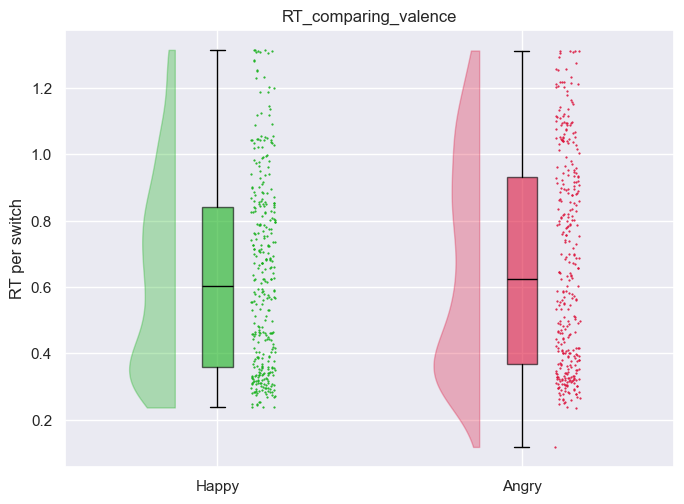

In [86]:
happy_dataframe = combined_dataframe[combined_dataframe['valence'] == 'happy']
happy_list = happy_dataframe['RT_s'].tolist()
angry_dataframe = combined_dataframe[combined_dataframe['valence'] == 'angry']
angry_list = angry_dataframe['RT_s'].tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Happy', 'Angry'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_valence'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

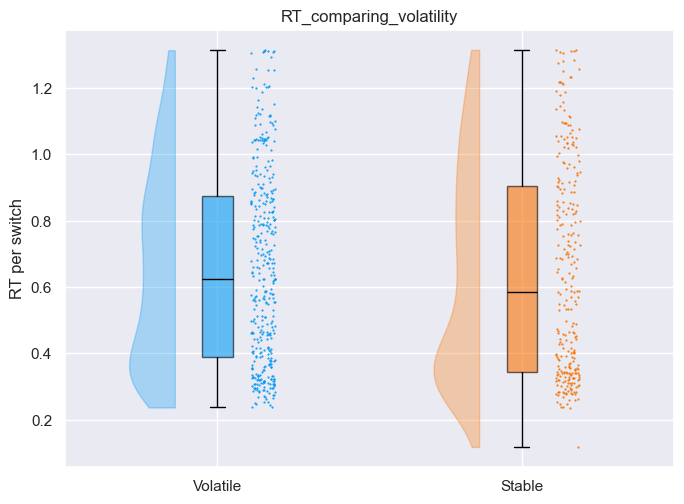

In [87]:
happy_dataframe = combined_dataframe[combined_dataframe['volatility'] == 'volatile']
happy_list = happy_dataframe['RT_s'].tolist()
angry_dataframe = combined_dataframe[combined_dataframe['volatility'] == 'stable']
angry_list = angry_dataframe['RT_s'].tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#069AF3', '#F97306']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Volatile', 'Stable'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_volatility'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

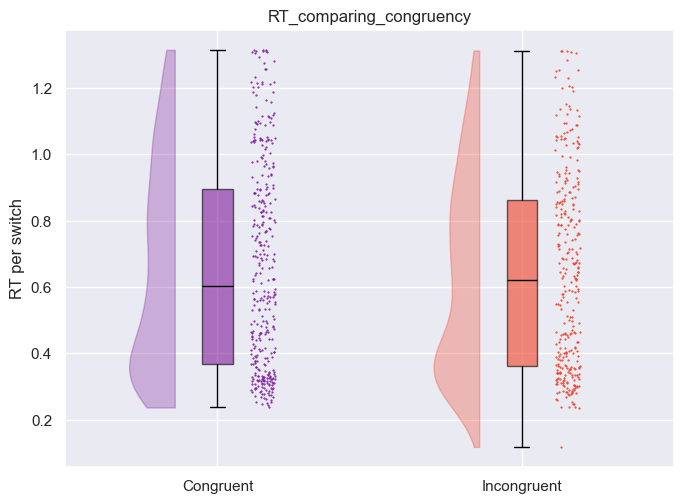

In [88]:
happy_dataframe = combined_dataframe[combined_dataframe['congruency'] == 'congruent']
happy_list = happy_dataframe['RT_s'].tolist()
angry_dataframe = combined_dataframe[combined_dataframe['congruency'] == 'incongruent']
angry_list = angry_dataframe['RT_s'].tolist()
valence_list = [happy_list, angry_list]

# Create empty plot
fig, ax = plt.subplots(figsize=(7, 5))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,3,1), ['Congruent', 'Incongruent'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_congruency'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

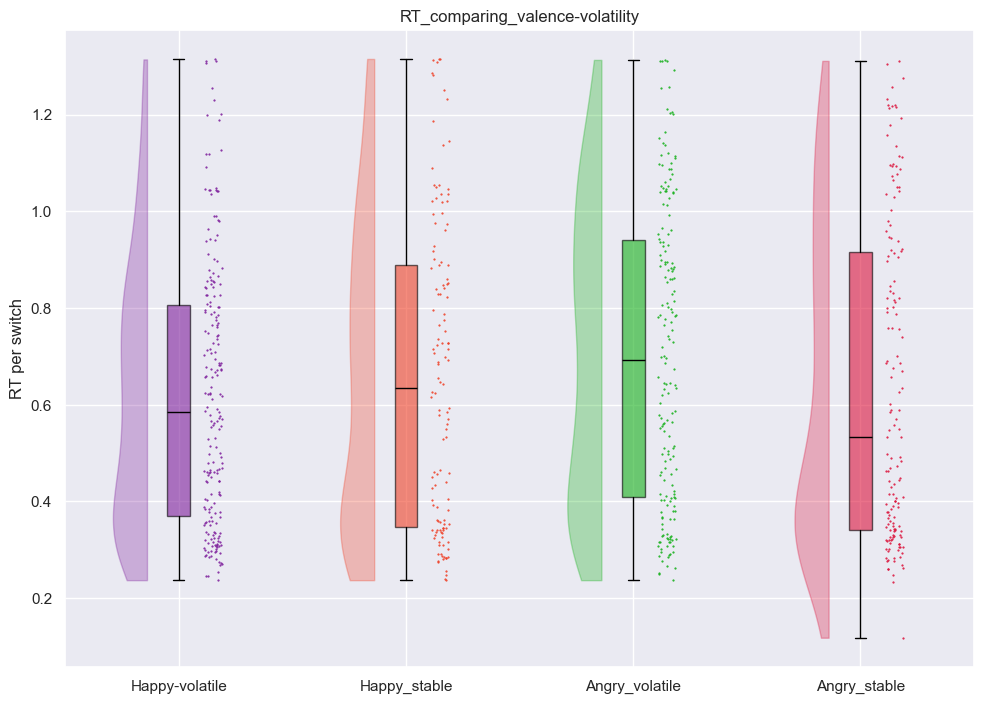

In [89]:
dataframe_1 = combined_dataframe[(combined_dataframe['valence'] == 'happy') & (combined_dataframe['volatility'] == 'volatile')]
list_1 = dataframe_1['RT_s'].tolist()
dataframe_2 = combined_dataframe[(combined_dataframe['valence'] == 'happy') & (combined_dataframe['volatility'] == 'stable')]
list_2 = dataframe_2['RT_s'].tolist()
dataframe_3 = combined_dataframe[(combined_dataframe['valence'] == 'angry') & (combined_dataframe['volatility'] == 'volatile')]
list_3 = dataframe_3['RT_s'].tolist()
dataframe_4 = combined_dataframe[(combined_dataframe['valence'] == 'angry') & (combined_dataframe['volatility'] == 'stable')]
list_4 = dataframe_4['RT_s'].tolist()
valence_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Happy-volatile', 'Happy_stable', 'Angry_volatile', 'Angry_stable'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_valence-volatility'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

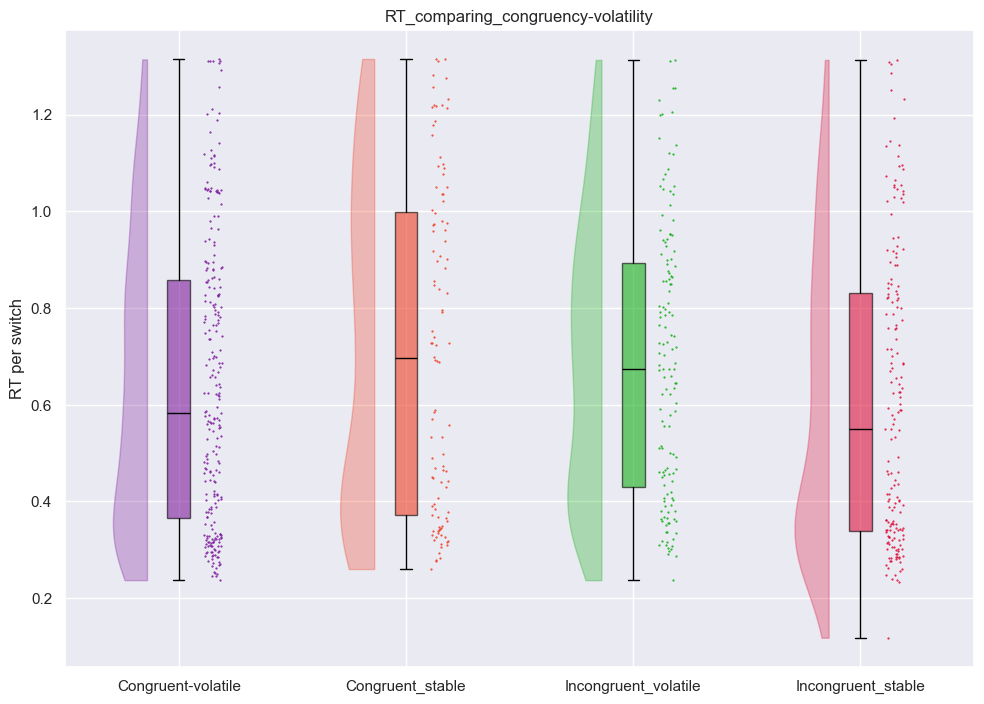

In [90]:
dataframe_1 = combined_dataframe[(combined_dataframe['congruency'] == 'congruent') & (combined_dataframe['volatility'] == 'volatile')]
list_1 = dataframe_1['RT_s'].tolist()
dataframe_2 = combined_dataframe[(combined_dataframe['congruency'] == 'congruent') & (combined_dataframe['volatility'] == 'stable')]
list_2 = dataframe_2['RT_s'].tolist()
dataframe_3 = combined_dataframe[(combined_dataframe['congruency'] == 'incongruent') & (combined_dataframe['volatility'] == 'volatile')]
list_3 = dataframe_3['RT_s'].tolist()
dataframe_4 = combined_dataframe[(combined_dataframe['congruency'] == 'incongruent') & (combined_dataframe['volatility'] == 'stable')]
list_4 = dataframe_4['RT_s'].tolist()
valence_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Congruent-volatile', 'Congruent_stable', 'Incongruent_volatile', 'Incongruent_stable'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_congruency-volatility'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

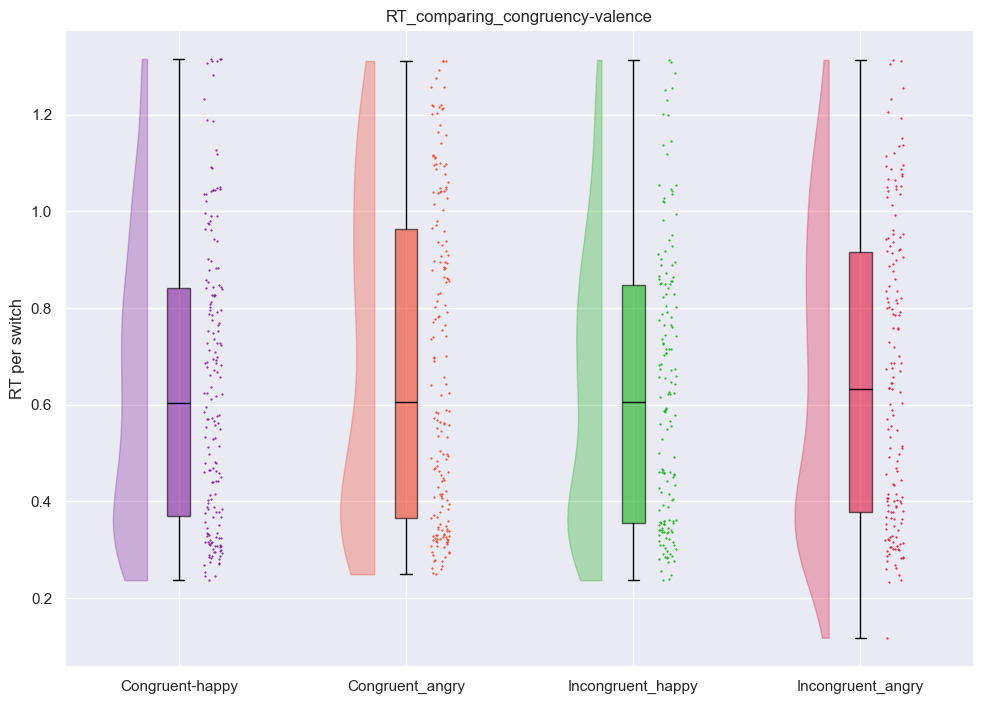

In [91]:
dataframe_1 = combined_dataframe[(combined_dataframe['congruency'] == 'congruent') & (combined_dataframe['valence'] == 'happy')]
list_1 = dataframe_1['RT_s'].tolist()
dataframe_2 = combined_dataframe[(combined_dataframe['congruency'] == 'congruent') & (combined_dataframe['valence'] == 'angry')]
list_2 = dataframe_2['RT_s'].tolist()
dataframe_3 = combined_dataframe[(combined_dataframe['congruency'] == 'incongruent') & (combined_dataframe['valence'] == 'happy')]
list_3 = dataframe_3['RT_s'].tolist()
dataframe_4 = combined_dataframe[(combined_dataframe['congruency'] == 'incongruent') & (combined_dataframe['valence'] == 'angry')]
list_4 = dataframe_4['RT_s'].tolist()
valence_list = [list_1, list_2, list_3, list_4]

# Create empty plot
fig, ax = plt.subplots(figsize=(10, 7))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,5,1), ['Congruent-happy', 'Congruent_angry', 'Incongruent_happy', 'Incongruent_angry'])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_congruency-valence'

# Save and show plot
plt.tight_layout()
plt.title(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()

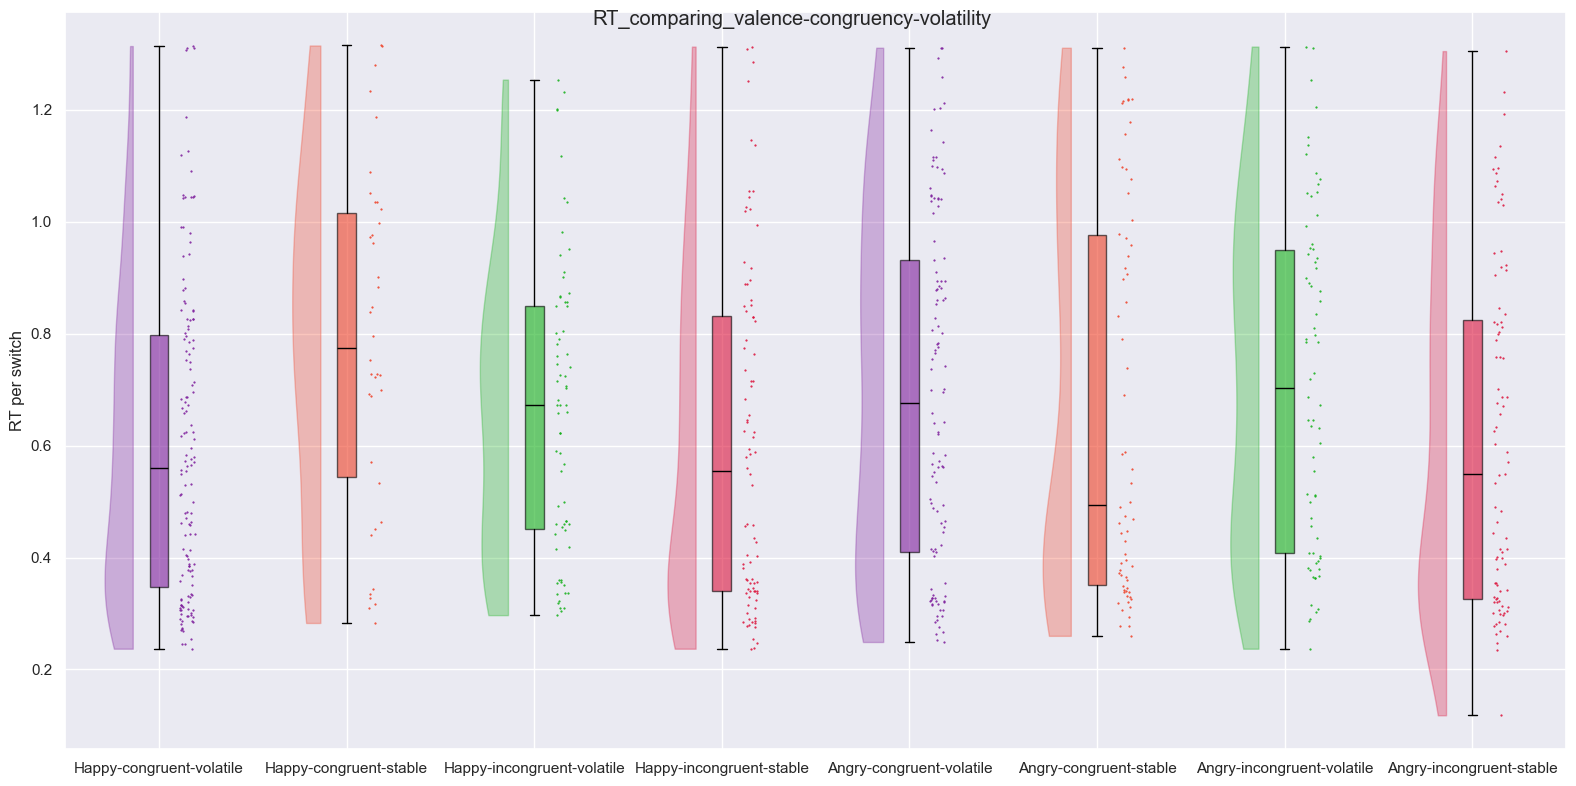

In [92]:
dataframe_1 = combined_dataframe[(combined_dataframe['valence'] == 'happy') & (combined_dataframe['congruency'] == 'congruent') & (combined_dataframe['volatility'] == 'volatile')]
list_1 = dataframe_1['RT_s'].tolist()
dataframe_2 = combined_dataframe[(combined_dataframe['valence'] == 'happy') & (combined_dataframe['congruency'] == 'congruent') & (combined_dataframe['volatility'] == 'stable')]
list_2 = dataframe_2['RT_s'].tolist()
dataframe_3 = combined_dataframe[(combined_dataframe['valence'] == 'happy') & (combined_dataframe['congruency'] == 'incongruent') & (combined_dataframe['volatility'] == 'volatile')]
list_3 = dataframe_3['RT_s'].tolist()
dataframe_4 = combined_dataframe[(combined_dataframe['valence'] == 'happy') & (combined_dataframe['congruency'] == 'incongruent') & (combined_dataframe['volatility'] == 'stable')]
list_4 = dataframe_4['RT_s'].tolist()
dataframe_5 = combined_dataframe[(combined_dataframe['valence'] == 'angry') & (combined_dataframe['congruency'] == 'congruent') & (combined_dataframe['volatility'] == 'volatile')]
list_5 = dataframe_5['RT_s'].tolist()
dataframe_6 = combined_dataframe[(combined_dataframe['valence'] == 'angry') & (combined_dataframe['congruency'] == 'congruent') & (combined_dataframe['volatility'] == 'stable')]
list_6 = dataframe_6['RT_s'].tolist()
dataframe_7 = combined_dataframe[(combined_dataframe['valence'] == 'angry') & (combined_dataframe['congruency'] == 'incongruent') & (combined_dataframe['volatility'] == 'volatile')]
list_7 = dataframe_7['RT_s'].tolist()
dataframe_8 = combined_dataframe[(combined_dataframe['valence'] == 'angry') & (combined_dataframe['congruency'] == 'incongruent') & (combined_dataframe['volatility'] == 'stable')]
list_8 = dataframe_8['RT_s'].tolist()
valence_list = [list_1, list_2, list_3, list_4, list_5, list_6, list_7, list_8]

# Create empty plot
fig, ax = plt.subplots(figsize=(16, 8))

# Create a list of colors
plot_colors = ['#7E1E9C', '#EF4026', '#15B01A', '#DC143C', '#7E1E9C', '#EF4026', '#15B01A', '#DC143C']
c = 'black'

# Boxplot data
bp = ax.boxplot(valence_list, patch_artist = True, vert = True, widths=0.1, boxprops=dict(facecolor=c, color=c),
                capprops=dict(color=c),
                whiskerprops=dict(color=c),
                flierprops=dict(color=c, markeredgecolor=c),
                medianprops=dict(color=c))
# Change to the desired color and add transparency
for patch, color in zip(bp['boxes'], plot_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('black')
# Violinplot data (specify points as length data)
vp = ax.violinplot(valence_list, points=500, positions=[0.86, 1.86, 2.86, 3.86, 4.86, 5.86, 6.86, 7.86], widths=0.3,
                   showmeans=False, showextrema=False, showmedians=False, vert=True, side = 'low')
# Change to the desired color
for idx, b in enumerate(vp['bodies']): # Slices it in half
    # Change to the desired color
    b.set_color(plot_colors[idx])

# Scatterplot data
for idx, features in enumerate(valence_list):
    # Add jitter effect so the features do not overlap on the y-axis
    x = np.full(len(features), idx + .75)
    idxs = np.arange(len(x))
    out = x.astype(float)
    out.flat[idxs] += np.random.uniform(low=-.04, high=.04, size=len(idxs))
    x = out + 0.4
    plt.scatter(x, features, s=.3, c=plot_colors[idx])

# Allocate labels to x- and y-axis
plt.xticks(np.arange(1,9,1), ['Happy-congruent-volatile', 'Happy-congruent-stable', 'Happy-incongruent-volatile', 'Happy-incongruent-stable', 'Angry-congruent-volatile', 'Angry-congruent-stable', 'Angry-incongruent-volatile', 'Angry-incongruent-stable', ])  # Set text labels.
plt.ylabel('RT per switch')
plot_name = 'RT_comparing_valence-congruency-volatility'

# Save and show plot
plt.tight_layout()
plt.suptitle(plot_name)
plt.savefig(os.path.join(output_dir, f'{plot_name}.pdf'))
plt.show()